# Exploratory Data Analysis (EDA)

## 1. Objetivo

En este notebook se realiza el análisis exploratorio del conjunto de datos final obtenido tras la limpieza y unión de los datasets de canciones y artistas.

El objetivo es comprender la estructura del dataset, analizar la distribución de las variables, identificar patrones y estudiar la relación entre las características musicales, la información de los artistas y la popularidad de las canciones.

## 2. Importación de librerías

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import sys
sys.path.append("../")
import matplotlib.pyplot as plt

from src import soporte_visualizacion as sv

## 3. Carga del dataset

Se carga el conjunto de datos final generado tras el proceso de limpieza y unión de los datasets de canciones y artistas.

In [2]:
df = pd.read_csv("../data/processed/music_dataset.csv")

## 4. Resumen general del dataset

Antes de comenzar el análisis exploratorio es necesario conocer las características generales del conjunto de datos.

En esta sección se revisan:

- Dimensiones del dataset.
- Tipos de datos.
- Valores ausentes.
- Variables numéricas.
- Variables categóricas.
- Filas duplicadas.

Este análisis permite detectar posibles incidencias antes de profundizar en el estudio de las variables.

In [3]:
# ==========================
# 4.1 Resumen general
# ==========================

sv.dataset_summary(df)

DATASET SUMMARY

Número de filas: 550,582
Número de columnas: 32
Número de duplicados: 0
Memoria utilizada: 440.81 MB

Tipos de datos:


,Tipo,Nulos,% Nulos
song_id,str,0,0.00
song_name,str,0,0.00
album_name,str,111,0.02
artists,str,0,0.00
danceability,float64,0,0.00
energy,float64,0,0.00
key,int64,0,0.00
loudness,float64,0,0.00
mode,str,0,0.00
speechiness,float64,0,0.00


### Comentarios

La revisión inicial muestra que el conjunto de datos se encuentra en buenas condiciones para comenzar el análisis. Apenas existen valores ausentes y los pocos que aparecen corresponden a casos puntuales ya identificados durante la fase de limpieza. Además, no se han detectado registros duplicados para una misma combinación de canción y artista.

In [4]:
# ==========================
# 4.2 Variables numéricas
# ==========================

display(
    sv.numeric_summary(df)
)

,count,mean,std,min,25%,50%,75%,max,median,iqr,missing,missing_%
danceability,550582.0,0.527,0.173,0.046,0.408,0.530,0.651,9.880000e-01,0.530,0.243,0,0.0
energy,550582.0,0.671,0.246,0.000,0.496,0.716,0.886,1.000000e+00,0.716,0.390,0,0.0
key,550582.0,5.275,3.558,0.000,2.000,5.000,8.000,1.100000e+01,5.000,6.000,0,0.0
loudness,550582.0,-7.878,3.859,-44.868,-9.907,-7.038,-5.095,0.000000e+00,-7.038,4.812,0,0.0
speechiness,550582.0,0.086,0.093,0.022,0.035,0.050,0.092,9.660000e-01,0.050,0.057,0,0.0
acousticness,550582.0,0.243,0.307,0.000,0.004,0.076,0.432,9.960000e-01,0.076,0.428,0,0.0
instrumentalness,550582.0,0.108,0.240,0.000,0.000,0.000,0.032,9.980000e-01,0.000,0.032,0,0.0
liveness,550582.0,0.224,0.197,0.007,0.100,0.141,0.294,1.000000e+00,0.141,0.194,0,0.0
valence,550582.0,0.465,0.249,0.000,0.259,0.447,0.660,9.980000e-01,0.447,0.401,0,0.0
tempo,550582.0,122.815,29.454,30.946,99.978,121.729,140.939,2.459410e+02,121.729,40.961,0,0.0


### Comentarios

Las variables numéricas no presentan valores ausentes, salvo una cantidad mínima en `popularity_per_million_followers`, por lo que no será necesario aplicar ningún tratamiento adicional.

Además, se aprecia una gran diferencia entre los valores mínimos y máximos de variables como los seguidores o la popularidad de los artistas, lo que indica que el conjunto de datos incluye tanto artistas poco conocidos como algunos de los más populares de Spotify.

In [5]:
# ==========================
# 4.3 Variables categóricas
# ==========================

display(
    sv.categorical_summary(df)
)

,Unique values,Missing,Most frequent,Frequency
song_id,550582,0,0001lyv0ytjkzsqzt4wkly,1
song_name,335596,0,home,227
album_name,135907,111,greatest hits,1972
artists,95015,0,['grateful dead'],1500
mode,2,0,major,367430
genre,10,0,rock,197152
artist_ids,95653,0,['4tmhgux5wi7oom53pqsdat'],1500
niche_genres,23638,0,[],6090
main_artist,43567,6,grateful dead,1601
decade,13,0,2010s,225336


### Comentarios

El conjunto de datos recoge una gran variedad de canciones, artistas y álbumes, lo que aporta una muestra amplia y diversa para el análisis.

También se observa que el género Rock es el más representado y que la mayoría de las canciones pertenecen a la década de 2010, reflejando un claro predominio de la música más reciente.

## 5. Análisis univariante

En esta sección se analiza la distribución de las principales variables del conjunto de datos de forma individual.

El objetivo es conocer cómo se distribuyen las canciones, los artistas y sus características musicales antes de estudiar las relaciones existentes entre ellas.

### 5.1 ¿Cómo son las canciones del dataset?

Se analiza la distribución de la popularidad y la duración de las canciones para conocer el perfil general del conjunto de datos.

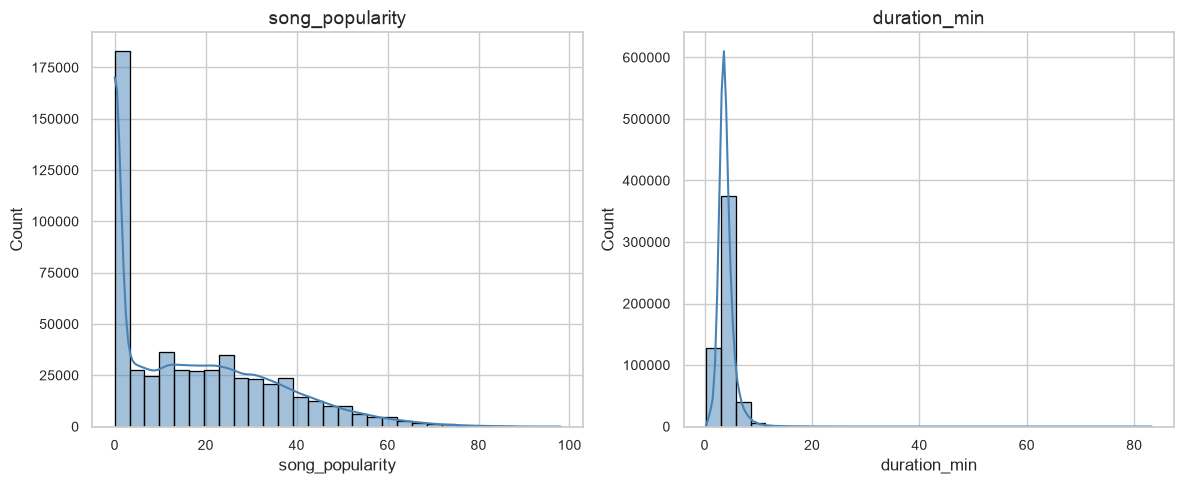

In [6]:
variables = [
    "song_popularity",
    "duration_min"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(12, 5)
)

plt.show()

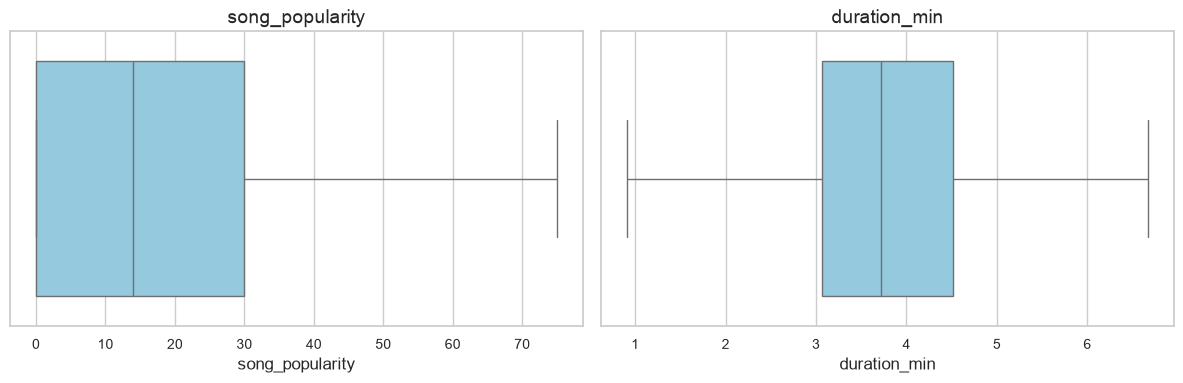

In [7]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(12, 4)
)

plt.show()

### Interpretación

La mayoría de las canciones del dataset presenta una popularidad baja, mientras que solo un pequeño número alcanza valores muy altos. En cuanto a la duración, la mayor parte de las canciones se sitúa entre los 3 y 4,5 minutos, una duración habitual en la música comercial.

Los boxplots muestran que la mayor concentración de valores se encuentra dentro de estos rangos, sin apreciarse una presencia destacable de valores atípicos.

## 5.2 ¿Cómo son los artistas del dataset?

En este apartado se analiza la distribución de la popularidad media y del número de seguidores asociados a los artistas de las canciones para conocer el perfil general de los artistas presentes en el conjunto de datos.

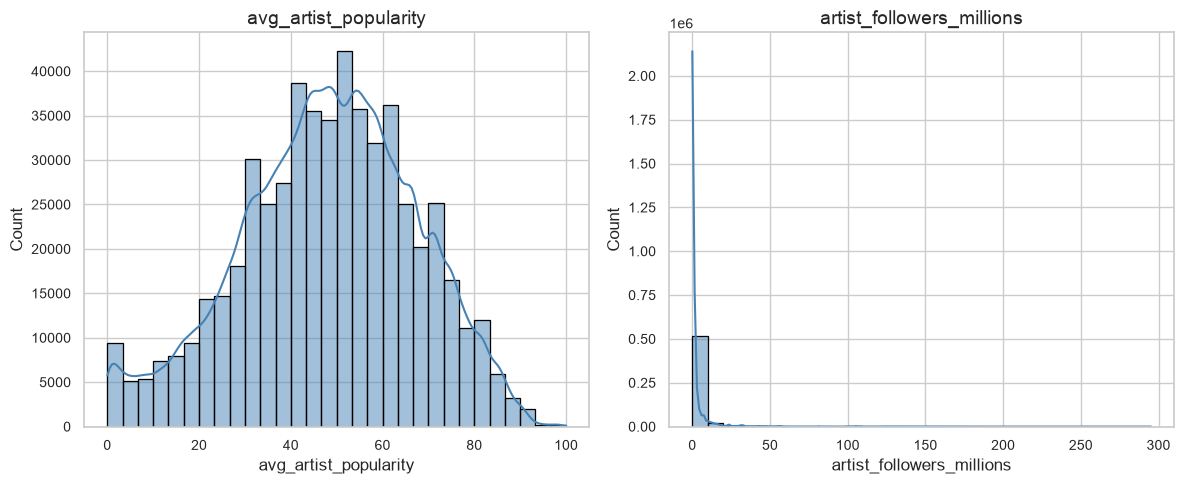

In [8]:
variables = [
    "avg_artist_popularity",
    "artist_followers_millions"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(12, 5)
)

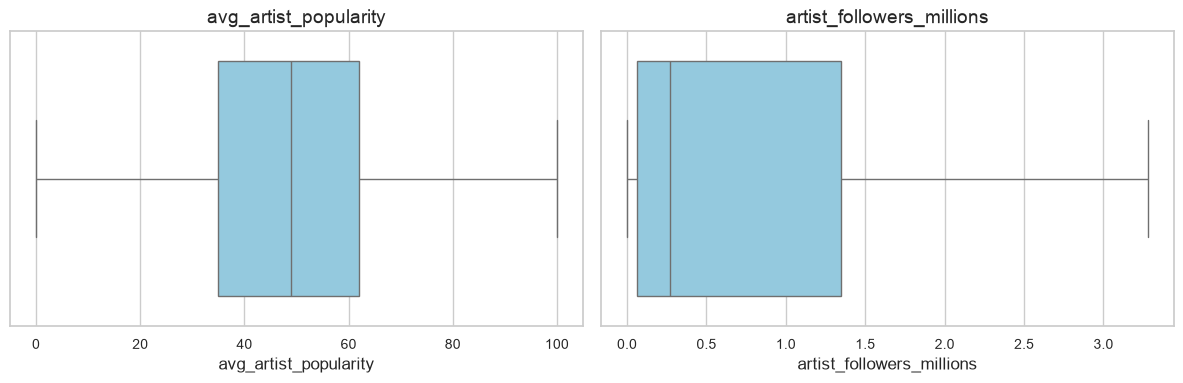

In [9]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(12, 4)
)

### Interpretación

Las canciones del dataset están asociadas principalmente a artistas con niveles de popularidad medios, mientras que solo una parte reducida presenta valores de popularidad muy elevados. En cuanto al número de seguidores asociados a los artistas, predominan las canciones vinculadas a artistas con audiencias más reducidas, mientras que un grupo minoritario está asociado a artistas con millones de seguidores.

Los boxplots reflejan esta distribución, mostrando una concentración elevada de observaciones en rangos relativamente reducidos de popularidad y seguidores, junto con algunos valores extremos correspondientes a canciones asociadas a artistas de mayor popularidad y alcance.

## 5.3 ¿Cómo son las características musicales de las canciones?

En este apartado se analizan algunas de las principales características musicales proporcionadas por Spotify para conocer el perfil general de las canciones del conjunto de datos.

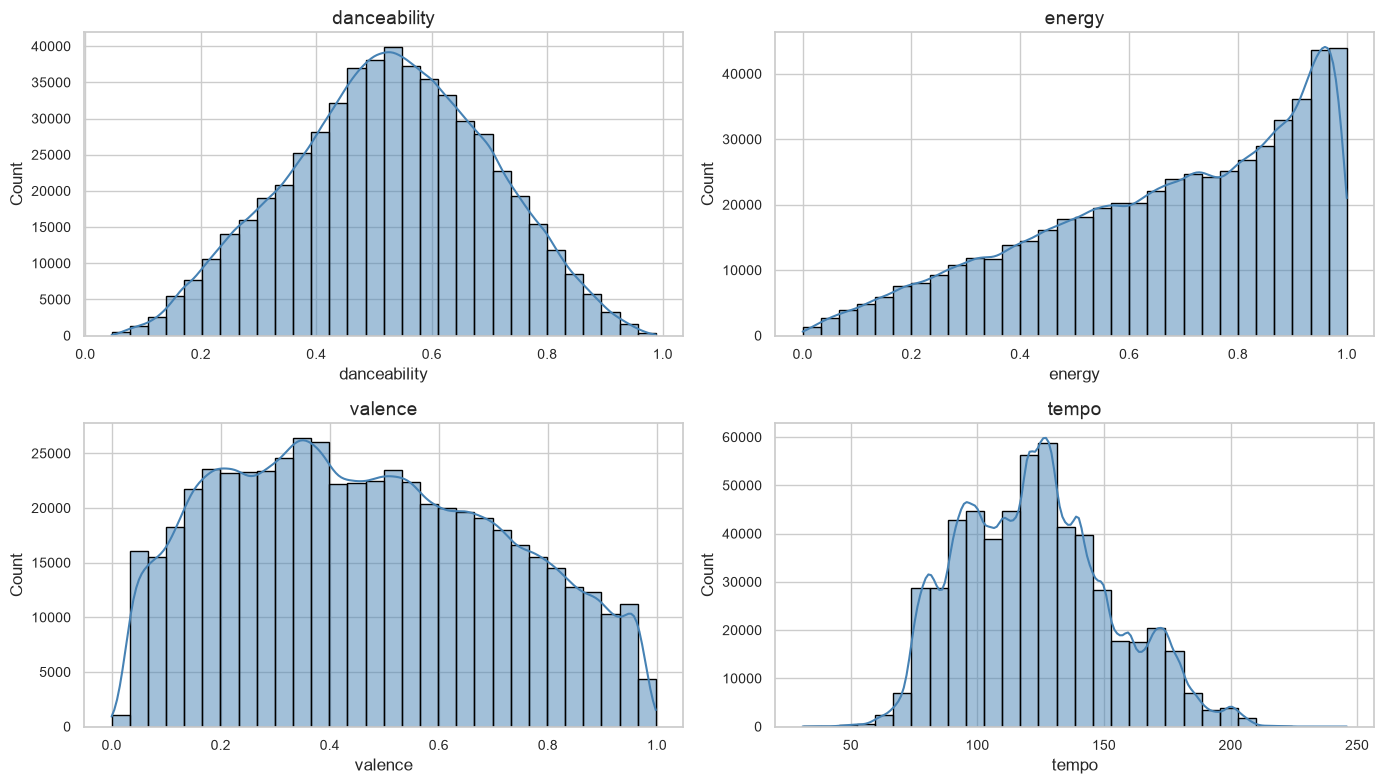

In [10]:
variables = [
    "danceability",
    "energy",
    "valence",
    "tempo"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(14,8)
)

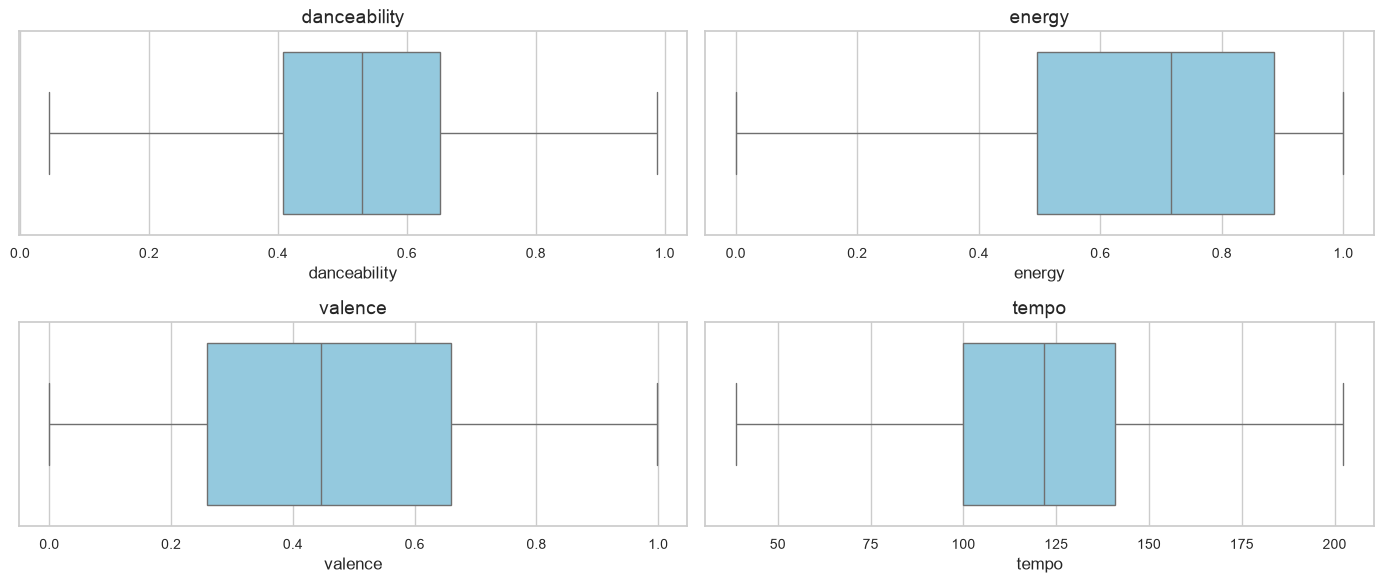

In [11]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(14,6)
)

### Interpretación

Las canciones del dataset presentan, en general, niveles medios de bailabilidad y valores elevados de energía, lo que indica un predominio de canciones dinámicas. La variable *valence* muestra una distribución más equilibrada, reflejando una mezcla de canciones con diferentes estados de ánimo.

Por su parte, el tempo se concentra principalmente entre los 100 y 140 BPM, con un pico alrededor de los 120 BPM, uno de los ritmos más habituales en la música actual. Los boxplots muestran una distribución bastante estable en todas las variables, sin una presencia significativa de valores atípicos.

# 6. ANÁLISIS BIVARIANTE

## 6.1 ¿Existe relación entre la popularidad media de los artistas y la de sus canciones?

Una de las primeras preguntas que podemos plantearnos es si las canciones asociadas a artistas más populares tienden a presentar también una mayor popularidad. Para ello se analiza la relación entre la popularidad media de los artistas asociados a cada canción y la popularidad de la canción mediante un gráfico de dispersión con línea de tendencia.


Pearson correlation: 0.394


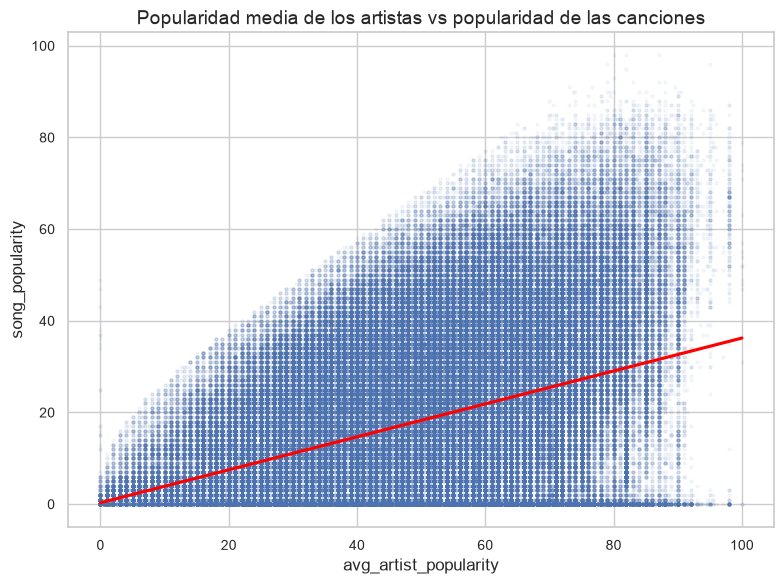

In [12]:
sv.correlation_value(
    df,
    x="avg_artist_popularity",
    y="song_popularity"
)

sv.regplot(
    df=df,
    x="avg_artist_popularity",
    y="song_popularity",
    figsize=(8, 6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Popularidad media de los artistas vs popularidad de las canciones"
)

### Interpretación

Se observa una relación positiva moderada-baja entre la popularidad media de los artistas asociados a una canción y la popularidad de la propia canción (r = 0.394). En general, las canciones asociadas a artistas con mayor popularidad tienden a presentar también una mayor popularidad, aunque la relación no es especialmente fuerte. La dispersión de los puntos indica que la popularidad de una canción depende también de otros factores. Por tanto, una mayor popularidad de los artistas asociados puede estar relacionada con un mayor éxito de sus canciones, pero no garantiza que todas ellas alcancen niveles elevados de popularidad.

## 6.2 ¿Las canciones más bailables son también las más populares?

La bailabilidad (*danceability*) es una de las características más representativas de Spotify. En este apartado se analiza si existe alguna relación entre la facilidad para bailar una canción y su popularidad.

Pearson correlation: 0.132


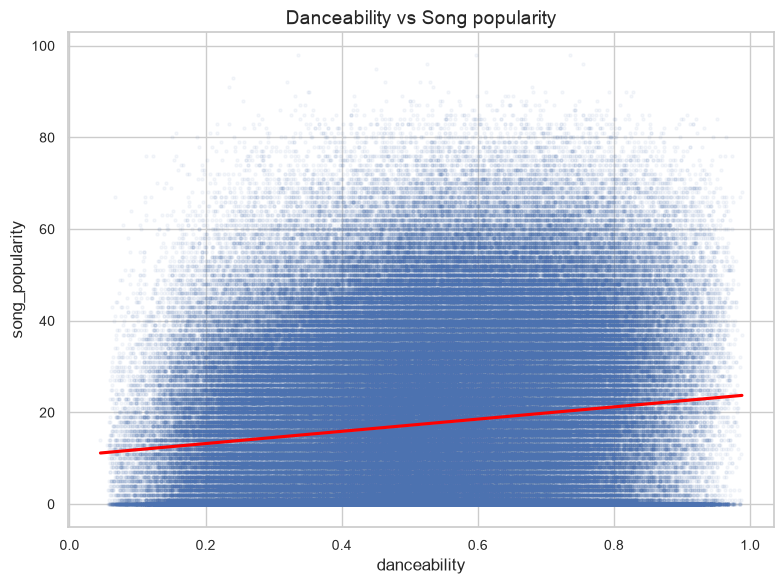

In [13]:
sv.correlation_value(
    df,
    x="danceability",
    y="song_popularity"
)
sv.regplot(
    df=df,
    x="danceability",
    y="song_popularity",
    figsize=(8,6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Danceability vs Song popularity"
)

### Interpretación

La relación entre la bailabilidad y la popularidad de las canciones es positiva, pero muy débil (r = 0.132). Aunque la línea de tendencia muestra un ligero incremento, la elevada dispersión de los datos indica que la relación entre ambas variables es limitada.

Esto sugiere que las canciones más bailables no son necesariamente las más populares y que el éxito de una canción depende de múltiples factores adicionales.

## 6.3 ¿Las canciones con más energía son también las más populares?

La energía (*energy*) mide la intensidad y el dinamismo percibido de una canción. En este apartado se analiza si las canciones más enérgicas tienden a alcanzar una mayor popularidad.

Pearson correlation: -0.019


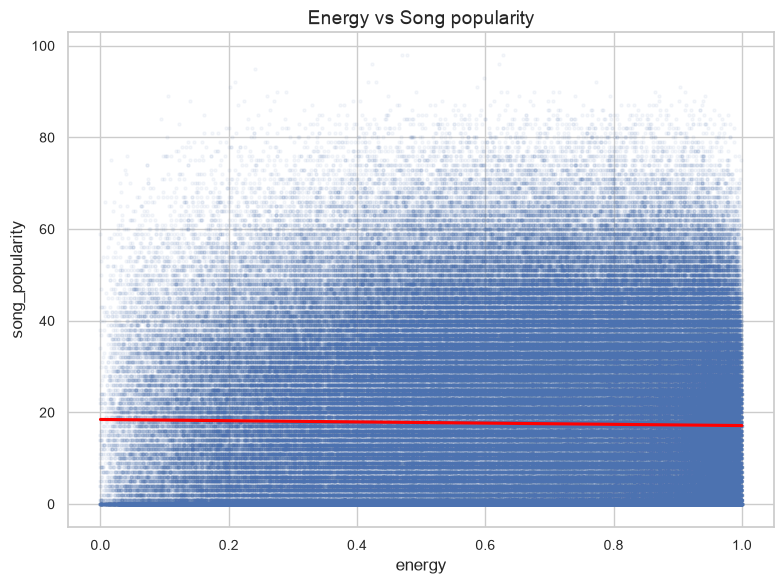

In [14]:
sv.correlation_value(
    df,
    x="energy",
    y="song_popularity"
)
sv.regplot(
    df=df,
    x="energy",
    y="song_popularity",
    figsize=(8,6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Energy vs Song popularity"
)

### Interpretación

No se observa una relación lineal relevante entre la energía de las canciones y su popularidad (r = -0.019). La línea de tendencia es prácticamente horizontal, lo que indica que ambas variables presentan una asociación lineal prácticamente inexistente en este conjunto de datos.

En este conjunto de datos es posible encontrar canciones populares tanto con niveles bajos como altos de energía, por lo que esta característica, por sí sola, no parece estar relacionada de forma significativa con la popularidad de una canción

## 6.4 ¿Qué géneros son los más populares?

Después de analizar algunas características musicales, resulta interesante comprobar si la popularidad varía según el género principal de la canción. Para ello se compara la popularidad media de cada género presente en el conjunto de datos.

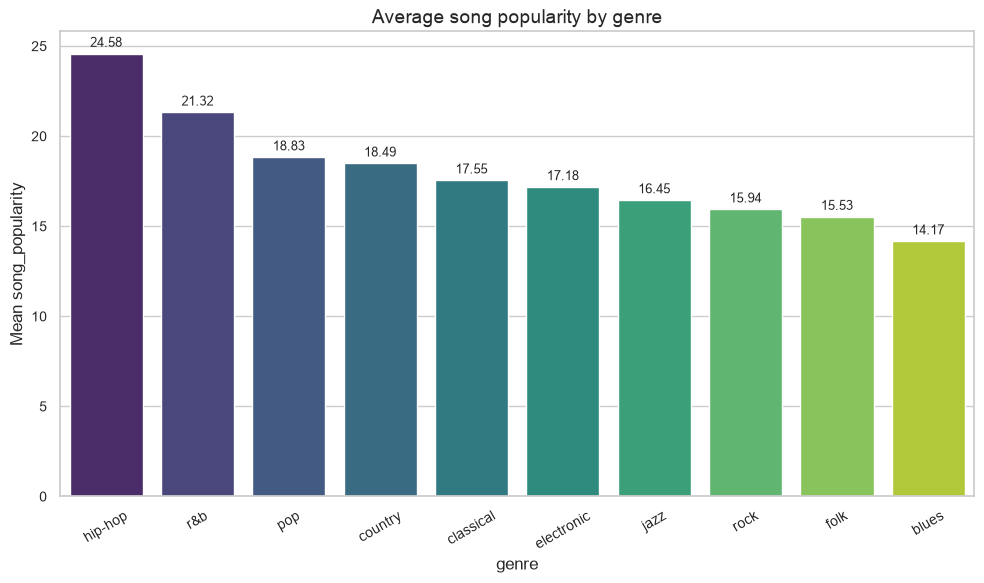

In [15]:
sv.grouped_barplot(
    df=df,
    groupby="genre",
    value="song_popularity",
    agg="mean",
    ascending=False,
    figsize=(10,6),
    rotation=30,
    palette="viridis",
    title="Average song popularity by genre"
)

### Interpretación
La popularidad media varía según el género musical. El hip-hop destaca como el género con mayor popularidad media (24,58), seguido de R&B (21,32). En cambio, géneros como blues, folk o rock presentan valores medios inferiores.

Aunque existen diferencias entre géneros, estas no son especialmente grandes, ya que la mayoría se concentra entre los 15 y 20 puntos de popularidad. Esto sugiere que el género puede influir en el éxito de una canción, pero probablemente no sea el único factor determinante.

## 6.5 ¿Ha cambiado la popularidad media de las canciones con el paso del tiempo?
La idea es comprobar si las canciones de las últimas décadas presentan, de media, una popularidad mayor o menor.

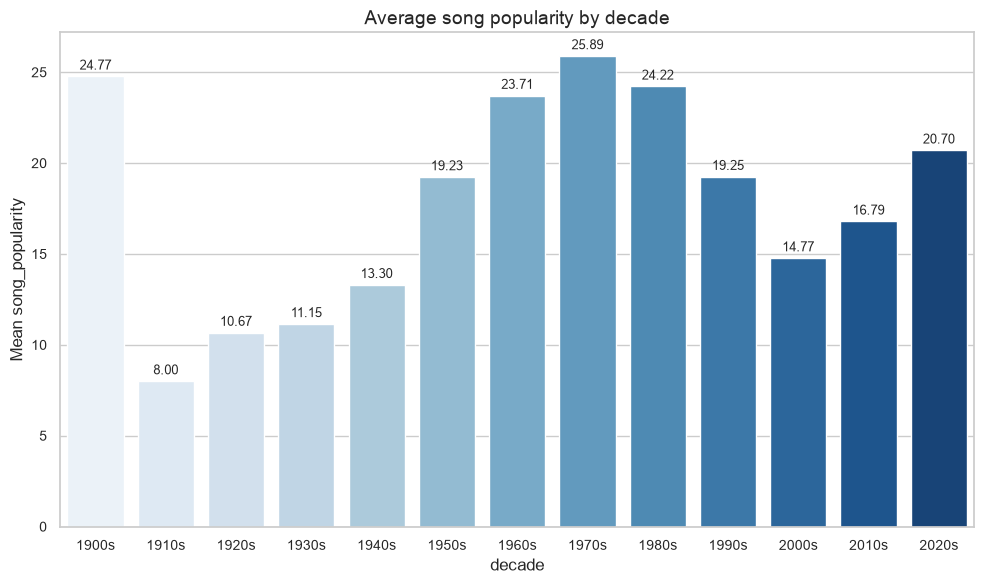

In [16]:
sv.grouped_barplot(
    df=df,
    groupby="decade",
    value="song_popularity",
    agg="mean",
    sort=False,
    rotation=0,
    palette="Blues",
    title="Average song popularity by decade"
)

### Interpretación

La popularidad media presenta una evolución desigual a lo largo del tiempo. Tras valores bajos en las primeras décadas, aumenta progresivamente hasta alcanzar su máximo en los años 70 (25,89) y se mantiene elevada en los 80. Posteriormente, desciende hasta su mínimo en los años 2000 (14,77) y vuelve a recuperarse en las décadas de 2010 y 2020.

Los resultados de las primeras décadas deben interpretarse con cautela, ya que cuentan con muchas menos canciones, especialmente los años 1900 y 1910. En cambio, las décadas más recientes concentran la mayor parte del dataset, por lo que sus medias son más representativas.

## 6.6 ¿En qué se diferencian las canciones más populares del resto?
En este apartado se comparan las características musicales del 10 % de las canciones con mayor popularidad con las del conjunto completo de canciones, con el objetivo de identificar qué rasgos diferencian a las canciones más exitosas.

In [17]:
top_songs = df[
    df["song_popularity"] >= df["song_popularity"].quantile(0.90)
]

variables = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "duration_min"
]

comparison = pd.DataFrame({
    "Dataset completo": df[variables].mean(),
    "Top 10% canciones": top_songs[variables].mean()
}).round(2)

display(comparison)

,Dataset completo,Top 10% canciones
danceability,0.53,0.59
energy,0.67,0.65
valence,0.46,0.49
tempo,122.82,121.95
duration_min,3.96,3.82


### Interpretación

En comparación con el conjunto completo del dataset, las canciones más populares presentan una mayor bailabilidad (0,59 frente a 0,53) y un valence ligeramente superior (0,49 frente a 0,46), lo que indica una tendencia hacia canciones algo más bailables y con un carácter emocional ligeramente más positivo.

Por el contrario, la energía es muy similar en ambos grupos (0,65 frente a 0,67), al igual que el tempo (121,95 frente a 122,82 BPM). Las canciones más populares son, además, ligeramente más cortas, con una duración media de 3,82 minutos frente a 3,96 minutos.

En conjunto, las mayores diferencias entre las canciones más populares y el conjunto general se observan en la bailabilidad y, en menor medida, en el valence, mientras que la energía, el tempo y la duración presentan diferencias más reducidas.

## 6.7 ¿Cómo se relacionan entre sí las principales variables numéricas?

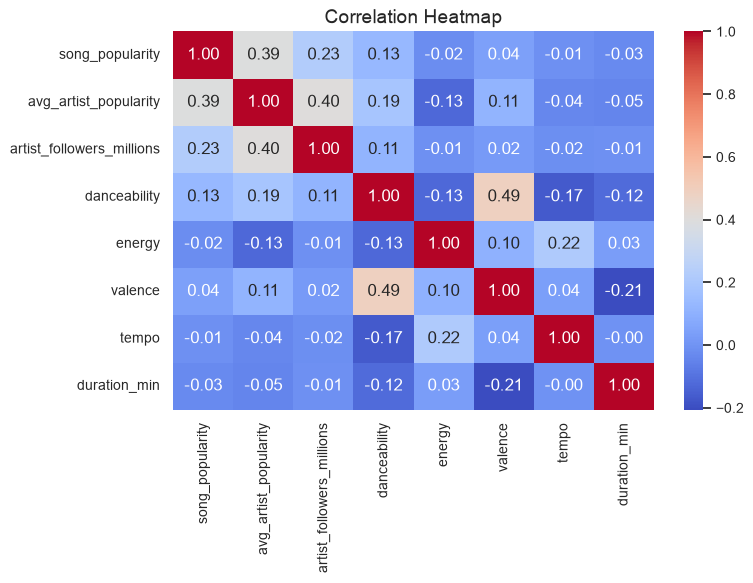

<Axes: title={'center': 'Correlation Heatmap'}>

In [18]:
variables_corr = [
    "song_popularity",
    "avg_artist_popularity",
    "artist_followers_millions",
    "danceability",
    "energy",
    "valence",
    "tempo",
    "duration_min"
]

sv.correlation_heatmap(
    df,
    columns=variables_corr,
    figsize=(8,6),
    cmap="coolwarm",
    annot=True
)

## Interpretación

La popularidad de las canciones se relaciona principalmente con la popularidad media de los artistas asociados (r = 0,39) y, en menor medida, con sus seguidores (r = 0,23). Entre las características musicales, la danceability presenta la mayor relación con la popularidad, aunque sigue siendo débil (r = 0,13).

También destaca la relación entre danceability y valence (r = 0,49). En conjunto, la popularidad de una canción presenta una mayor asociación con la popularidad y el alcance del artista que con sus características musicales.

# 7. Conclusiones del EDA

El análisis exploratorio muestra que la mayoría de las canciones del dataset tienen una duración habitual de entre 3 y 4,5 minutos y niveles medios de bailabilidad y energía. La popularidad, sin embargo, está concentrada principalmente en valores bajos, con un grupo reducido de canciones muy populares.

Los resultados indican que la popularidad de una canción presenta una mayor asociación con la popularidad de los artistas que con sus características musicales. La popularidad media de los artistas asociados presenta la mayor correlación con la popularidad de las canciones (0,39), seguida del número de seguidores (0,23).

Entre las características musicales, la bailabilidad es la que presenta una mayor relación con la popularidad (0,13). Además, las canciones más populares presentan una mayor bailabilidad (0,59 frente a 0,53) y un valence ligeramente superior, mientras que variables como la energía, el tempo y la duración presentan diferencias más reducidas.

También se observan diferencias de popularidad entre géneros y décadas, aunque estos resultados deben interpretarse teniendo en cuenta la distribución desigual de las canciones en el dataset, especialmente en las primeras décadas.

En conjunto, el EDA sugiere que el éxito de una canción está más asociado con la popularidad y el alcance del artista que con unas características musicales concretas.